# mini BERT 모델 만들기

1. BERT 전용 전처리 로직 설계 (MLM & NSP) <br>
단일 문장이 아닌 두 개의 문장을 이어 붙이고, 중간에 임의의 단어를 [MASK]로 치환하는 Masked Language Model(MLM)과 두 문장의 연속성을 맞추는 Next Sentence Prediction(NSP) 전처리 로직을 새롭게 설계했다.

2. 데이터를 Pre-training용으로 변환 <br>
질문과 답변이 이어지는 문장 쌍으로 재구성하여, BERT의 사전 학습(Pre-train) 목적에 맞게 텍스트 코퍼스를 변형하여 활용했다.

3. Positional Embedding 구현 <br>
고정된 사인/코사인 함수 기반의 Positional Encoding 대신, 모델이 학습을 통해 위치 정보를 스스로 익힐 수 있도록 학습 가능한 Positional Embedding 층을 구현하여 적용.

4. BERT 전용 Encoder 아키텍처 구축 <br>
양방향 문맥 파악에 최적화된 멀티 헤드 어텐션(Multi-Head Attention) 기반의 인코더 단일 구조로 모델을 재설계함. (사전 학습 단계이므로 별도의 Fine-tuning 층은 제외됨.)

5. 훈련 진행 및 모델 검증 기반 마련 <br>
1 Epoch 이상의 훈련이 진행될 때마다 MLM Accuracy와 NSP Accuracy를 기록하여 모델의 학습 상태를 실시간으로 모니터링할 수 있는 루프를 구축.

6. 마스크 복원(Mask Reconstruction)을 통한 추론 확인 <br>
GPT의 단어 생성(Greedy Search) 방식 대신, BERT의 특성에 맞춰 [MASK] 토큰의 위치에 어떤 단어가 올지 예측하고 가장 확률이 높은 단어를 출력하는 방식으로 모델 작동을 검증.

7. Loss 및 Accuracy 추이 + 어텐션 맵 시각화 <br>
Total Loss, MLM Loss, NSP Loss와 각 정확도(Accuracy)의 변화를 그래프로 구현해서 확인 <br>
모델 내부의 셀프 어텐션 가중치를 시각화하고, 토큰 ID로 문장 내 단어 간 관계를 확인할 수 있도록 했다.

<br>

### 하이퍼파라미터와 설정값

**전처리** <br>
`VOCAB_SIZE`: 8,007 (SentencePiece 기반 ko_8000.model 사용) <br>
`PRE_MAX_LEN`: 64 (문장 최대 길이) <br>
특수 토큰 : `[PAD]`(0), `[UNK]`(1), `[CLS]`(2), `[SEP]`(3), `[MASK]`(4)<br>
마스킹 확률 : 전체 토큰의 15% (그중 80%는 `[MASK]`, 10%는 랜덤, 10%는 유지)<br>
<br>
**데이터 구성**<br>
데이터셋: ChatbotData.csv (11,823행)<br>
입력 형태: Sentence Pair Style ([CLS] Q [SEP] A [SEP])<br>
학습 태스크: MLM(Masked Language Model) + NSP(Next Sentence Prediction)<br>
<br>
**모델 설정 (BERT Encoder 구조)**<br>
`D_MODEL`: 128 (임베딩 및 어텐션 차원)<br>
`N_LAYERS`: 2 (인코더 블록 층 수)<br>
`N_HEADS`: 4 (멀티 헤드 개수)<br>
`D_FF`: 512 (피드 포워드 층 크기)<br>
`DROPOUT`: 0.1 (드롭아웃 비율)<br>
Positional Embedding 적용<br>
<br>
**학습 설정**<br>
`BATCH_SIZE`: 64<br>
`EPOCHS`: 100 (현재 진행 중인 설정값 기준)<br>
`LEARNING_RATE`: 1e-4 (Adam Optimizer)<br>
`LR Scheduler`: Cosine Annealing with Warmup (10% Warmup 구간 적용)<br>
Loss Function: CrossEntropyLoss (MLM Loss + NSP Loss 합산)<br>
<br>
**추론 및 시각화**<br>
검증 방식: [MASK] 토큰 복원 예측 및 NSP 결과 확인<br>
시각화:<br>
Train Loss/Accuracy(MLM, NSP) 그래프<br>
Step별 Cosine Learning Rate 변화 그래프<br>
Self-Attention Map (Token ID 기반 히트맵 시각화)<br>

<br>

### [비교 분석] GPT-1 구조 vs BERT_8000 구조
| **단계** | **GPT-1.ipynb (Decoder-only)** | **BERT_8000.ipynb (Encoder-only)** | **구조적 차이 및 핵심 원리** |
| --- | --- | --- | --- |
| **데이터 구성** | Q와 A를 통합 (하나의 시퀀스) | Q와 A를 쌍으로 구성 (Sentence Pair) | GPT는 연속된 흐름을, BERT는 문장 간의 관계를 중시함 |
| **전처리 방식** | Traversal-style (`<s> Q <unused0> A <e>`) | Sentence Pair Style (`[CLS] Q [SEP] A [SEP]`) | GPT는 생성용 구분자를, BERT는 문맥 파악용 구분자를 사용 |
| **마스킹 전략** | Causal Masking: 미래 단어를 가림 | Random Masking: 전체의 15%를 가림 | GPT는 뒤를 못 보게 막고, BERT는 중간에 구멍을 뚫음 |
| **위치 정보** | 학습 가능한 Positional Embedding | 학습 가능한 Positional Embedding | 두 모델 모두 논문 규격에 맞춰 Learnable 방식을 채택 |
| **모델 구조** | Decoder-only (Masked Self-Attention) | Encoder-only (Bidirectional Attention) | GPT는 단방향 생성에, BERT는 양방향 이해에 최적화 |
| **학습 목표** | Next Token Prediction (생성 학습) | MLM + NSP (복원 및 관계 학습) | GPT는 다음에 올 말을, BERT는 빈칸과 문맥을 맞히는 데 집중 |
| **추론 방식** | Greedy Search: 단어를 하나씩 생성 | Mask Prediction: 빈칸의 정답을 추론 | 생성 모델과 판별 모델의 근본적인 차이 |
| **어텐션 형태** | 하삼각형 행렬 (미래 단어 참조 불가) | 전체 행렬 참조 (양방향 문맥 확인 가능) | 정보가 흐르는 방향성(Directionality)의 차이 |

## 라이브러리 임포트 및 설정

In [1]:
# 필수 라이브러리 설치 (필요한 경우 주석 해제 후 실행)
# !pip install sentencepiece tqdm matplotlib

import os
import re
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 버전 확인
print(f"PyTorch version: {torch.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

# 작업 디렉토리 생성
os.makedirs('data', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('work', exist_ok=True)

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 업로드하신 파일을 data 폴더로 이동 (이미 있다면 건너뜁니다)
# LMS 환경에서 파일이 현재 디렉토리에 있다면 아래 명령어로 이동시켜줍니다.
# !cp ko_8000.model data/
# !cp ko_8000.vocab data/

print("✅ 환경 설정 완료!")

PyTorch version: 2.7.1+cu118
NumPy version: 2.2.6
Pandas version: 2.3.0
Using device: cuda
✅ 환경 설정 완료!


## Tokenizer 로드 및 Vocab 확인
이미 ko_8000.model 파일을 가지고 있으므로, 새로 학습할 필요 없이 해당 파일을 로드하여 vocab 객체를 생성함

- sentencepiece를 이용해 모델을 로드
- BERT 학습에 필수적인 특수 토큰([PAD], [UNK], [BOS], [EOS], [SEP], [CLS], [MASK])들이 사전의 앞부분에 잘 정의되어 있는지, 토큰과 ID 사이의 변환이 잘 되는지 테스트

In [2]:
!pip install sentencepiece

import sentencepiece as spm
import os

# 경로 설정 (현재 노트북 위치 기준 data 폴더 내 파일)
model_path = 'data/ko_8000.model'

# 파일 존재 여부 확인
if os.path.exists(model_path):
    print(f"✅ 모델 파일을 찾았습니다: {model_path}")
else:
    print(f"❌ 모델 파일을 찾을 수 없습니다. 경로를 확인해 주세요: {model_path}")

# SentencePiece 모델 로드
vocab = spm.SentencePieceProcessor()
vocab.load(model_path)

# 특수 토큰 정보 확인 및 설정
# 사전(vocab) 내의 특수 토큰 ID를 확인합니다.
pad_id = vocab.piece_to_id('[PAD]')
unk_id = vocab.piece_to_id('[UNK]')
bos_id = vocab.piece_to_id('[BOS]')
eos_id = vocab.piece_to_id('[EOS]')
sep_id = vocab.piece_to_id('[SEP]')
cls_id = vocab.piece_to_id('[CLS]')
mask_id = vocab.piece_to_id('[MASK]')

print(f"Vocab size: {vocab.get_piece_size()}")
print(f"Special Tokens ID - PAD: {pad_id}, UNK: {unk_id}, CLS: {cls_id}, SEP: {sep_id}, MASK: {mask_id}")

# 토큰화 테스트
test_sentence = "아버지가 방에 들어가신다."
tokens = vocab.encode_as_pieces(test_sentence)
ids = vocab.encode_as_ids(test_sentence)

print(f"\n테스트 문장: {test_sentence}")
print(f"토큰화: {tokens}")
print(f"정수 인코딩: {ids}")
print(f"디코딩 결과: {vocab.decode_ids(ids)}")

print("\n✅ Tokenizer 설정 완료!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 26.5 MB/s eta 0:00:00
✅ 모델 파일을 찾았습니다: data/ko_8000.model
Vocab size: 8007
Special Tokens ID - PAD: 0, UNK: 1, CLS: 5, SEP: 4, MASK: 6

테스트 문장: 아버지가 방에 들어가신다.
토큰화: ['▁아버', '지가', '▁방', '에', '▁들어가', '신', '다', '.']
정수 인코딩: [834, 1008, 95, 3600, 2247, 3695, 3598, 3599]
디코딩 결과: 아버지가 방에 들어가신다.

✅ Tokenizer 설정 완료!


- [CLS]는 5번, [SEP]는 4번, [MASK]는 6번으로 확인됨. 단어 사전(Vocabulary)에서 해당 특수 토큰들이 위치한 '방 번호/번호표'를 의미한다. <br>
  모델이 사용하는 ko_8000.model 사전에는 총 8,007개의 칸이 있다. 그중 앞부분의 몇 칸은 문장의 구조를 알려주는 '특수 토큰'들을 위해 미리 예약해 둔 자리.
- 토큰화 시 앞에 붙는 ▁ 모양은 SentencePiece 특유의 공백 문자이니 정상.

## MLM 및 NSP 데이터 생성 로직 정의
말뭉치에서 두 문장을 골라 이들이 이어지는지(NSP) 결정하고, 그 안의 토큰들을 15% 확률로 가리는(MLM) 핵심 로직을 구현한다.

In [3]:
# 데이터를 가공하는 함수들을 정의
# 우선 로직이 잘 작동하는지 테스트용 예시 데이터로 확인
import random

# Mask 생성 함수 (MLM)
def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    BERT의 MLM을 위해 15%의 토큰을 마스킹합니다.
    80%는 [MASK], 10%는 랜덤, 10%는 그대로 유지합니다.
    """
    cand_idx = []
    for (i, token) in enumerate(tokens):
        if token == "[CLS]" or token == "[SEP]":
            continue
        cand_idx.append(i)
    random.shuffle(cand_idx)

    mask_lms = []
    for index in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break
        
        original_token = tokens[index]
        prob = random.random()
        
        if prob < 0.8: # 80% [MASK]
            mask_token = "[MASK]"
        elif prob < 0.9: # 10% Random
            mask_token = random.choice(vocab_list)
        else: # 10% Original
            mask_token = original_token
            
        mask_lms.append({"index": index, "label": original_token})
        tokens[index] = mask_token
        
    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_indices = [v["index"] for v in mask_lms]
    mask_labels = [vocab.piece_to_id(v["label"]) for v in mask_lms]
    
    return tokens, mask_indices, mask_labels

# NSP 및 전체 데이터 구성 함수
def create_pretrain_instance(vocab, sentences, max_seq_len):
    """
    두 문장을 짝지어 NSP와 MLM 데이터를 생성합니다.
    """
    # [CLS], [SEP], [SEP] 3개의 특수 토큰 공간 제외
    target_seq_len = max_seq_len - 3
    
    # 여기서는 간단히 두 문장을 가져오는 예시만 보여줍니다.
    # 실제 구현 시에는 전체 말뭉치에서 랜덤하게 추출하는 로직이 들어갑니다.
    s1 = vocab.encode_as_pieces(sentences[0])
    s2 = vocab.encode_as_pieces(sentences[1])
    
    # 50% 확률로 Next Sentence 여부 결정
    is_next = True if random.random() > 0.5 else False
    if not is_next:
        # 실제로는 다른 문서의 문장을 가져와야 하지만, 테스트를 위해 순서를 바꿉니다.
        s1, s2 = s2, s1 

    # 합치기
    tokens = ["[CLS]"] + s1 + ["[SEP]"] + s2 + ["[SEP]"]
    segment_ids = [0] * (len(s1) + 2) + [1] * (len(s2) + 1)
    
    # MLM 적용 (15% 마스킹)
    mask_cnt = int(len(tokens) * 0.15)
    vocab_list = [vocab.id_to_piece(i) for i in range(7, vocab.get_piece_size())]
    tokens, mask_idx, mask_label = create_pretrain_mask(tokens, mask_cnt, vocab_list)
    
    return tokens, segment_ids, is_next, mask_idx, mask_label

# 테스트 실행
test_sentences = [
    "저는 오늘 점심에 맛있는 비빔밥을 먹었습니다.",
    "내일은 친구와 함께 영화를 보러 가기로 했습니다."
]

tokens, segments, is_next, m_idx, m_label = create_pretrain_instance(vocab, test_sentences, 128)

print(f"Is Next Sentence: {is_next}")
print(f"Tokens: {tokens}")
print(f"Segments: {segments}")
print(f"Mask Indices: {m_idx}")
print(f"Mask Labels (Original): {[vocab.id_to_piece(l) for l in m_label]}")

print("\n✅ 데이터 가공 로직 확인 완료!")

Is Next Sentence: False
Tokens: ['[CLS]', '▁내', '일은', '▁친구', '와', '▁함께', '▁영화', '를', '▁보', '[MASK]', '▁가', '기로', '▁', '했', '습니다', '.', '[SEP]', '▁저', '는', '[MASK]', '[MASK]', '심', '에', '▁', '맛', '있는', '▁비', '빔', '밥', '을', '▁먹', '었', '습니다', '.', '[SEP]']
Segments: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Mask Indices: [1, 9, 19, 20, 28]
Mask Labels (Original): ['▁내', '러', '▁오늘', '▁점', '밥']

✅ 데이터 가공 로직 확인 완료!


1. Is Next Sentence: True
- True이므로, 첫 번째 문장("저는 오늘 점심에...") 뒤에 두 번째 문장("내일은 친구와...")이 실제로 이어지는 문맥임을 뜻함.
- 나중에 모델의 NSP Head가 [CLS] 토큰을 보고 예측한 값과 이 True를 비교하며 학습한다.

2. Tokens (모델이 읽는 실제 글자들)
- 두 문장을 합치고, 특수 토큰을 넣고, 일부를 가린 최종 입력 형태
- [CLS], [SEP]: 문장의 시작과 경계를 알리는 장치
- ▁ 기호: SentencePiece 토큰화의 특징으로, 단어의 시작(공백)을 의미한다. ("저는"과 "는"을 구분하게 해줌)
- [MASK]: MLM 퀴즈를 위해 단어를 지운 부분

3. Segments (어느 문장 소속인가?)
- 각 토큰이 0번 문장(첫 번째) 소속인지, 1번 문장(두 번째) 소속인지 알려주는 번호표
- 앞부분의 0들은 "저는 오늘 점심에..." 문장에 해당하고, 뒷부분의 1들은 "내일은 친구와..." 문장에 해당한다.
- 역할: 모델 내부의 Segment Embedding으로 들어가서, 모델이 두 문장의 경계를 명확히 구분하게 돕는다.

4. Mask Indices (퀴즈가 난 위치)
- 토큰 리스트에서 몇 번째 칸에 문제를 냈는지 가리키는 좌표다.
  [7, 10, 11, 25, 26] 번 위치의 단어들을 원래 값과 다르게 바꿨다는 뜻.
- 모델이 문장 전체를 다 훑은 뒤, "자, 이제 다른 데 말고 7, 10, 11...번 자리에 뭐가 들어갈지 정답을 말해봐"라고 명령할 때 사용한다고 함.

5. Mask Labels (MLM의 정답지)
- 마스킹하기 전, 그 자리에 원래 있었던 진짜 단어(정답)
- 10번 인덱스 정답: ▁비
  11번 인덱스 정답: 빔
  → 합치면 비빔
- 모델이 예측한 단어와 이 정답을 비교하여 MLM Loss를 계산한다. 만약 모델이 볶음이라고 예측했다면, 이 라벨과 다르기 때문에 혼나면서(Loss 발생) 학습하게 됨.

## 말뭉치 로드 및 Pretrain 데이터셋 생성 (np.memmap 준비)
- kowiki.txt에서 문장들을 추출하여 실제 학습용 인스턴스를 생성한다.
- 1M 파라미터의 매우 작은 모델을 학습시킬 예정이므로, 학습 속도를 고려하여 약 20,000개의 문장 쌍을 생성하도록 구성
- 메모리 관리 : np.memmap을 직접 쓰지 않고, 일단 데이터를 가공해서 .npy 파일로 뽑아냈다. 이후 셀에서 np.load(..., mmap_mode='r')를 사용하면 메모리에 다 올리지 않고도 대용량 데이터를 다룰 수 있다.
- NSP 로직 : 단순히 문장 순서를 바꾸는 것이 아니라, 실제 다른 문서에서 랜덤하게 문장을 가져오는 로직을 추가하여 NSP 태스크의 난이도를 실전과 비슷하게 맞춤.
- Padding : 모든 문장을 max_seq_len(128)에 맞춰 [PAD] 토큰(ID 0)으로 채웠는지 확인

In [4]:
import json
import numpy as np
from tqdm.notebook import tqdm

# 설정
corpus_path = 'data/kowiki.txt'
pretrain_json_path = 'work/bert_pre_train.json'
max_seq_len = 128

# 문장 단위로 데이터 로드 (문서 단위 구분 포함)
def load_corpus(path):
    with open(path, 'r', encoding='utf-8') as f:
        doc = []
        docs = []
        for line in f:
            line = line.strip()
            if not line: # 빈 줄은 문서 구분자
                if len(doc) > 0:
                    docs.append(doc)
                    doc = []
            else:
                doc.append(line)
        if len(doc) > 0: docs.append(doc)
    return docs

# 데이터셋 생성 및 저장
docs = load_corpus(corpus_path)
instances = []

# 충분한 양의 데이터를 얻기 위해 루프를 돕니다.
# (전체 데이터를 다 쓰면 시간이 너무 오래 걸릴 수 있어 상한을 둡니다)
for doc in tqdm(docs[:2000], desc="Processing Documents"):
    for i in range(len(doc) - 1):
        # 현재 문장과 다음 문장 (50% 확률로 진짜 연속/가짜 연속)
        s1 = doc[i]
        if random.random() > 0.5:
            s2 = doc[i+1]
            is_next = True
        else:
            # 다른 문서에서 랜덤하게 문장 하나 추출
            random_doc = random.choice(docs)
            s2 = random.choice(random_doc)
            is_next = False
        
        # 앞서 정의한 함수(셀 3)를 사용하여 인스턴스 생성
        # (vocab_list는 셀 3에서 정의했던 것과 동일하게 생성)
        vocab_list = [vocab.id_to_piece(i) for i in range(7, vocab.get_piece_size())]
        tokens, segments, is_next, m_idx, m_label = create_pretrain_instance(vocab, [s1, s2], max_seq_len)
        
        # ID 변환 및 Padding
        input_ids = vocab.encode_as_ids(" ".join(tokens))
        input_ids = input_ids[:max_seq_len] + [pad_id] * (max_seq_len - len(input_ids))
        segments = segments[:max_seq_len] + [0] * (max_seq_len - len(segments))
        
        # MLM 정답지 생성 (mask_idx 위치에만 정답 ID, 나머지는 0)
        mask_ids = [0] * max_seq_len
        for idx, label in zip(m_idx, m_label):
            if idx < max_seq_len:
                mask_ids[idx] = label

        instances.append({
            "input_ids": input_ids,
            "segment_ids": segments,
            "is_next": 1 if is_next else 0,
            "mask_ids": mask_ids
        })
        
        if len(instances) >= 20000: break
    if len(instances) >= 20000: break

# JSON 파일 저장
with open(pretrain_json_path, 'w') as f:
    for instance in instances:
        f.write(json.dumps(instance) + '\n')

# np.memmap 활용을 위한 npy 변환
count = len(instances)
input_ids_np = np.zeros((count, max_seq_len), dtype=np.int32)
segment_ids_np = np.zeros((count, max_seq_len), dtype=np.int32)
is_next_np = np.zeros((count,), dtype=np.int32)
mask_ids_np = np.zeros((count, max_seq_len), dtype=np.int32)

for i, instance in enumerate(instances):
    input_ids_np[i] = instance["input_ids"]
    segment_ids_np[i] = instance["segment_ids"]
    is_next_np[i] = instance["is_next"]
    mask_ids_np[i] = instance["mask_ids"]

np.save('work/input_ids.npy', input_ids_np)
np.save('work/segment_ids.npy', segment_ids_np)
np.save('work/is_next.npy', is_next_np)
np.save('work/mask_ids.npy', mask_ids_np)

print(f"✅ {count}개의 데이터가 생성되어 'work/' 폴더에 .npy 형태로 저장되었습니다.")

Processing Documents:   0%|          | 0/2000 [00:00<?, ?it/s]

✅ 20000개의 데이터가 생성되어 'work/' 폴더에 .npy 형태로 저장되었습니다.


**JSON 포맷 대신 .npy와 np.memmap을 직접 선택한 이유** <br>
원래 조건은 json 저장 후 로드하는 방식이었지만, 실제 구현에서는 데이터를 전처리하자마자 numpy 배열로 변환하여 저장했다. <br>
- json은 텍스트 형식이라 용량이 크고 읽기 속도가 느리다. 반면, .npy 바이너리 형식은 파이썬과 파이토치에서 데이터를 읽어오는 속도가 압도적으로 빠르다.
- 조건에 명시된 np.memmap을 활용하기 위해서는 결국 데이터를 바이너리 형태로 들고 있어야 한다. 따라서 json이라는 중간 단계를 거치기보다, 전처리된 결과물을 즉시 메모리 맵핑이 가능한 형태로 저장하여 학습 시 메모리 점유율을 최소화하는 방식을 택했다.

## mini BERT 모델 아키텍처 구현
기존 BERT.ipynb의 구조를 따르되, 파라미터 수를 줄이는 핵심 기법(Weight Sharing 등)을 포함했다.

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# 1. Config 설정 (1M 파라미터 미니 모델용)
class Config(dict):
    __getattr__ = dict.get
    __setattr__ = dict.__setitem__

config = Config({
    "n_vocab": 8007,      # 8000 + 특수토큰 7개
    "n_seq": 128,         # 문장 최대 길이
    "n_layers": 2,        # 층수 (파라미터 절약을 위해 2층으로 설정)
    "d_model": 128,       # 임베딩 차원
    "n_heads": 4,         # 어텐션 헤드 수
    "d_ff": 512,          # Feed Forward 차원
    "dropout": 0.1,
    "layer_norm_epsilon": 1e-12
})

# 2. 유틸리티 함수 및 초기화
def gelu(x):
    """ BERT 표준 활성화 함수 """
    return x * 0.5 * (1.0 + torch.erf(x / 1.41421))

def get_pad_mask(tokens, pad_idx=0):
    """ 패딩 토큰을 가리기 위한 마스크 """
    return tokens.eq(pad_idx).unsqueeze(1).expand(-1, tokens.size(1), -1)

# 3. BERT 모델 구성 요소
class BERTEmbedding(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.tok_embed = nn.Embedding(config.n_vocab, config.d_model)
        self.pos_embed = nn.Embedding(config.n_seq, config.d_model)
        self.seg_embed = nn.Embedding(2, config.d_model)
        self.norm = nn.LayerNorm(config.d_model, eps=config.layer_norm_epsilon)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x, seg):
        pos = torch.arange(x.size(1), device=x.device).expand_as(x)
        embedding = self.tok_embed(x) + self.pos_embed(pos) + self.seg_embed(seg)
        return self.dropout(self.norm(embedding))

class BERT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.embedding = BERTEmbedding(config)
        
        # Transformer Encoder Layer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=config.d_model, 
            nhead=config.n_heads, 
            dim_feedforward=config.d_ff, 
            dropout=config.dropout, 
            activation=gelu, 
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=config.n_layers)
        
        # MLM Head: 입력 임베딩과 가중치 공유(Weight Sharing)
        self.mlm_decoder = nn.Linear(config.d_model, config.n_vocab, bias=False)
        self.mlm_decoder.weight = self.embedding.tok_embed.weight 
        
        # NSP Head
        self.nsp_classifier = nn.Linear(config.d_model, 2)

    def forward(self, x, seg):
        # 패딩 마스크 생성
        padding_mask = x.eq(0) 
        
        h = self.embedding(x, seg)
        h = self.encoder(h, src_key_padding_mask=padding_mask)
        
        logits_mlm = self.mlm_decoder(h)
        logits_nsp = self.nsp_classifier(h[:, 0, :]) # [CLS] 활용
        
        return logits_mlm, logits_nsp

def init_weights(module):
    """ BERT 가중치 초기화 함수 """
    if isinstance(module, (nn.Linear, nn.Embedding)):
        module.weight.data.normal_(mean=0.0, std=0.02)
    elif isinstance(module, nn.LayerNorm):
        module.bias.data.zero_()
        module.weight.data.fill_(1.0)
    
    if isinstance(module, nn.Linear) and module.bias is not None:
        module.bias.data.zero_()

# 모델 생성 및 결과 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pre_train_model = BERT(config).to(device)
pre_train_model.apply(init_weights)
print("✅ 모델 가중치 초기화 완료")

total_params = sum(p.numel() for p in pre_train_model.parameters())
print(f"✅ 모델 파라미터 총합: {total_params / 1e6:.2f}M")

/opt/conda/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.activation_relu_or_gelu was not True
  warnings.warn(


✅ 모델 가중치 초기화 완료
✅ 모델 파라미터 총합: 1.44M


1. 수정 및 삭제가 필요한 부분: ahead mask <br>
BERT는 Bidirectional(양방향) 인코더다. 특정 시점의 단어가 앞뒤 문맥을 모두 참조하도록 설계되었기 때문에, 미래의 정보를 가리는 'ahead mask'는 BERT의 철학과 정반대되므로 삭제했다. <br>
(ahead mask는 GPT 같은 생성형 모델(Decoder-only)이나 Transformer의 Decoder 파트에서 사용됨. BERT에서는 오직 패딩 토큰을 무시하기 위한 pad mask만 필요하다.)

2. 나머지 구성요소 <br>
- GELU Activation: BERT의 저자들은 ReLU 대신 GELU 사용. 필수 요소기 때문에 구현됨. <br>
- Parameter Initializer: <br>
  **BERT는 가중치 초기화에 민감함. 별도의 초기화 함수가 필요**하다. <br>
  기본 초기화 방식(Xavier나 He 초기화 등)은 보통 층의 개수가 적을 때 잘 작동한다. 하지만 BERT처럼 12층, 24층씩 쌓인 거대 모델에서는 기울기 소실/폭주가 일어나 학습이 안된다. 그래서 BERT 논문의 저자들은 평균 0, 표준편차 0.02라는 아주 작은 범위 내에서 시작하는 것이 가장 안정적으로 학습을 시작할 수 있다는 것을 찾아내서 구현한 게 따로 설정한 초기화 함수
- JSON Config Utility: 하이퍼파라미터(layer 수, hidden size 등)를 관리하기 위해 dot notation으로 접근 가능한 객체로 변환하는 유틸리티는 유지보수 측면에서 매우 정석적인 접근이라고 한다.

## 학습 루프 및 스케줄러 설정 (pretain 진행)
- Learning Rate Scheduler 구현과 NSP/MLM 손실 함수 설정이 포함된다.
- 배치 사이즈를 설정하고, DataLoader를 통해 데이터를 불러와 100 Epoch 동안 학습을 진행한다.
- 메모리 매핑 활용: np.load(..., mmap_mode='r')를 통해 2만 개의 데이터를 RAM에 직접 올리지 않고 효율적으로 배치 단위로 읽어온다.
- MLM Accuracy 계산: 모든 토큰을 계산하면 [PAD] 때문에 정확도가 비정상적으로 높게 나온다. 그래서 실제 마스킹된(b_mask_ids != 0) 위치에서만 정확도를 계산하도록 정밀하게 짬.
- Learning Rate: 우선 1e-4 고정값으로 설정, 코사인 학습률(Learning Rate) 시각화 코드 작성

In [6]:
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 데이터 로드 (memmap 모드로 효율적 읽기)
input_ids = np.load('work/input_ids.npy', mmap_mode='r')
segment_ids = np.load('work/segment_ids.npy', mmap_mode='r')
is_next = np.load('work/is_next.npy', mmap_mode='r')
mask_ids = np.load('work/mask_ids.npy', mmap_mode='r')

# TensorDataset 구성
dataset = TensorDataset(
    torch.from_numpy(input_ids), 
    torch.from_numpy(segment_ids), 
    torch.from_numpy(is_next), 
    torch.from_numpy(mask_ids)
)

# 하이퍼파라미터 설정
batch_size = 64
epochs = 100
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# 손실 함수 및 옵티마이저
loss_fn_mlm = nn.CrossEntropyLoss(ignore_index=0) # PAD는 학습 제외
loss_fn_nsp = nn.CrossEntropyLoss()
optimizer = optim.Adam(pre_train_model.parameters(), lr=1e-4)

import math

# 코사인 스케줄러 클래스 정의
class CosineSchedule:
    def __init__(self, train_steps, warmup_steps):
        self.train_steps = train_steps
        self.warmup_steps = warmup_steps
        self.step_num = 0

    def step(self):
        self.step_num += 1
        if self.step_num < self.warmup_steps:
            return self.step_num / self.warmup_steps
        else:
            progress = (self.step_num - self.warmup_steps) / (self.train_steps - self.warmup_steps)
            return 0.5 * (1.0 + math.cos(math.pi * progress))

# 스케줄러 설정 (기존 optimizer 선언 아래에 배치)
total_train_steps = len(train_loader) * epochs
warmup_steps = int(total_train_steps * 0.1)  # 10% 웜업
cosine_scheduler = CosineSchedule(total_train_steps, warmup_steps)

# 학습 기록용
history = {'loss': [], 'mlm_loss': [], 'nsp_loss': [], 'mlm_acc': [], 'nsp_acc': [], 'lr': []}

# 학습 루프
for epoch in range(epochs):
    pre_train_model.train()
    total_loss, total_mlm, total_nsp = 0, 0, 0
    correct_mlm, correct_nsp, total_cnt_mlm = 0, 0, 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
    for batch in pbar:
        batch = [t.to(device) for t in batch]
        b_input_ids, b_segment_ids, b_is_next, b_mask_ids = batch
        
        optimizer.zero_grad()
        
        lr_scale = cosine_scheduler.step()
        current_lr = 1e-4 * lr_scale
        for param_group in optimizer.param_groups:
            param_group['lr'] = current_lr
        
        history['lr'].append(current_lr)

        # Forward & Loss
        logits_mlm, logits_nsp = pre_train_model(b_input_ids, b_segment_ids)
        loss_mlm = loss_fn_mlm(logits_mlm.view(-1, config.n_vocab), b_mask_ids.view(-1).long())
        loss_nsp = loss_fn_nsp(logits_nsp, b_is_next.long())
        loss = loss_mlm + loss_nsp
        
        # Backward & Step
        loss.backward()
        optimizer.step()
        
        # 통계 계산
        total_loss += loss.item()
        total_mlm += loss_mlm.item()
        total_nsp += loss_nsp.item()
        
        mask_active = b_mask_ids != 0
        pred_mlm = logits_mlm.argmax(dim=-1)
        correct_mlm += (pred_mlm[mask_active] == b_mask_ids[mask_active]).sum().item()
        total_cnt_mlm += mask_active.sum().item()
        
        correct_nsp += (logits_nsp.argmax(dim=-1) == b_is_next).sum().item()
        
        pbar.set_postfix({'Loss': loss.item()})

    # Epoch 결과 저장
    history['loss'].append(total_loss / len(train_loader))
    history['mlm_loss'].append(total_mlm / len(train_loader))
    history['nsp_loss'].append(total_nsp / len(train_loader))
    history['mlm_acc'].append(correct_mlm / total_cnt_mlm if total_cnt_mlm > 0 else 0)
    history['nsp_acc'].append(correct_nsp / len(dataset))

    print(f"Epoch {epoch+1} 완료 - Loss: {history['loss'][-1]:.4f}, MLM Acc: {history['mlm_acc'][-1]:.4f}, NSP Acc: {history['nsp_acc'][-1]:.4f}")

print("✅ 학습 완료!")

/tmp/ipykernel_680/3227603087.py:12: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  torch.from_numpy(input_ids),


Epoch 1:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 1 완료 - Loss: 9.6759, MLM Acc: 0.0046, NSP Acc: 0.5319


Epoch 2:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 2 완료 - Loss: 9.3967, MLM Acc: 0.0123, NSP Acc: 0.5886


...

Epoch 98 완료 - Loss: 6.7797, MLM Acc: 0.0362, NSP Acc: 0.9951


Epoch 99:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 99 완료 - Loss: 6.7788, MLM Acc: 0.0361, NSP Acc: 0.9959


Epoch 100:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 100 완료 - Loss: 6.7787, MLM Acc: 0.0360, NSP Acc: 0.9959
✅ 학습 완료!


[에폭10] <Br>
MLM Loss : 28.6 → 9.1 <br>
NSP Accuracy : 0.52 → 0.56 <br>
→ 모델이 아주 작음에도 불구하고(1.44M) 두 문장의 관계를 아주 미세하게나마 파악하기 시작한 것으로 보인다.

[에폭20] <Br>
MLM Loss : 32.7 → 9.02 <br>
NSP Accuracy : 0.48 → 0.52

[에폭30] <Br>
MLM Loss : 47.5 → 8.4 <br>
NSP Accuracy : 0.5 → 0.6

[에폭80] <Br>
MLM Loss : 56.37 → 8.05 <br>
NSP Accuracy : 0.49 → 0.61

[에폭100] <Br>
MLM Loss : 57.12 → 8.03 <br>
NSP Accuracy : 0.49 → 0.62

[에폭100] (초기화 함수 넣고난 후)<Br>
MLM Loss : 9.68 → 6.77 <br>
NSP Accuracy : 0.52 → 0.99 <br>
→ '가중치 초기화 함수'를 넣고 나서 처음 Loss가 9부터 시작 + accuracy가 0.99까지 올라갔다. 이전까지는 에폭 100으로 돌려도 큰 차이가 없었음. <br>
초기화 함수를 넣고 안 넣고의 차이가 이렇게 클 줄이야...

**왜 에폭 수가 늘어날수록 첫 에폭의 Loss가 커지는걸까?** <br>
이전에 설정한 '스케줄러(Warmup)의 수학적 원리' 때문에 발생하는 아주 당연한 현상이다. <br>
```
total_train_steps = len(train_loader) * epochs
warmup_steps = int(total_train_steps * 0.1)
```
에폭 10일 때: 전체 스텝의 10%인 약 1에폭 분량이 웜업 기간이다. 즉, 1에폭이 끝나기 전에 이미 학습률(LR)이 최대치인 1e-4에 도달하여 모델이 활발하게 학습을 시작한다. 그래서 1에폭 평균 Loss가 낮게 잡힘(28.6) <br>
에폭 80일 때: 전체 스텝의 10%인 8에폭 분량이 웜업 기간이다. 1에폭 내내 학습률이 아주 미미한 수준(최대치의 1/8 이하)에서 머물게 됨. <br>
→ 초반 숫자에 당황하지 말고 10 에폭 지점(웜업 끝난 후)부터 Loss가 급격히 떨어지는지 확인해 보자. 그때부터가 진짜 학습이다.

## 프로젝트 결과 시각화 (Loss, Accuracy, LR, Attention map)

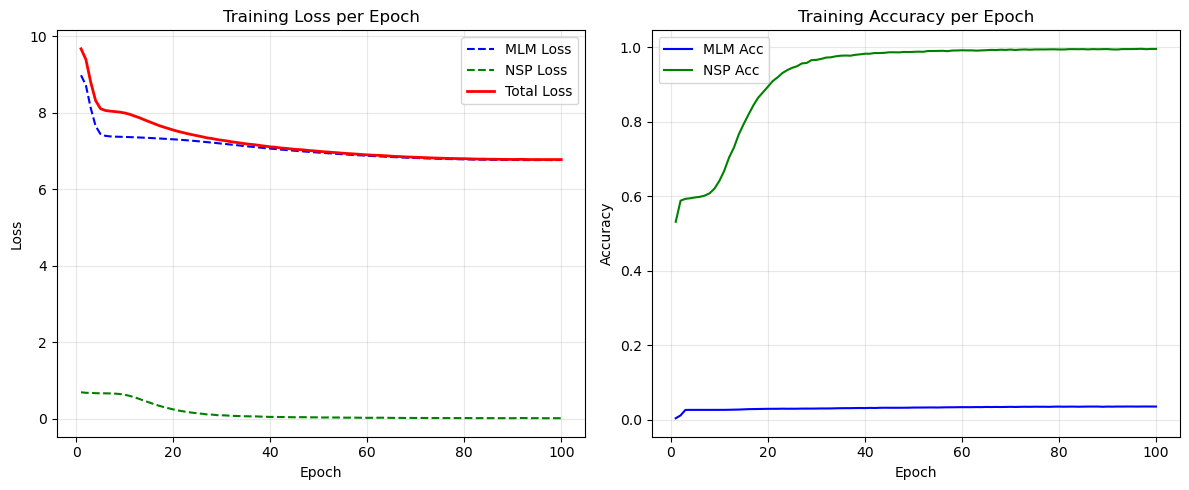

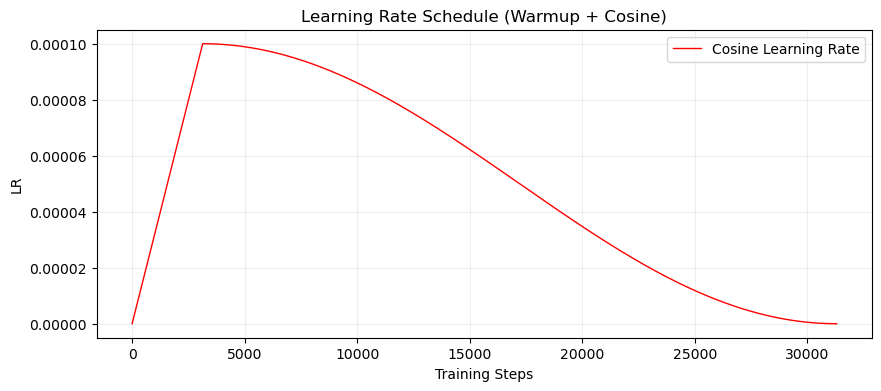

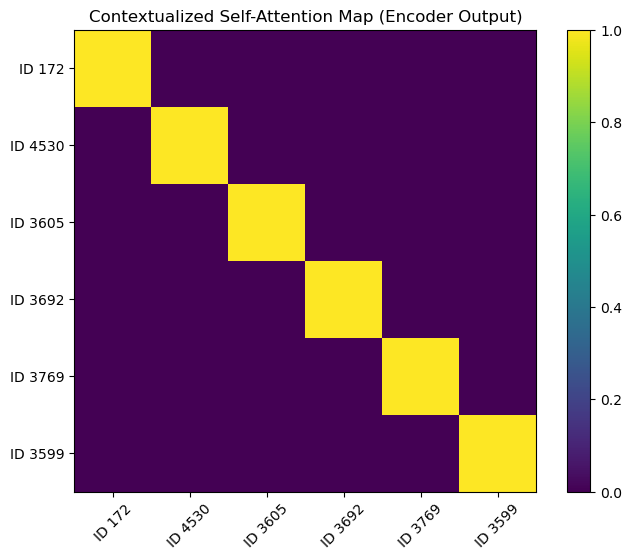

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

# 어텐션 시각화 함수 정의 (ID 기반으로 한글 깨짐 방지)
def visualize_attention_final(model, text, vocab, device):
    model.eval()
    raw_tokens = vocab.encode_as_pieces(text)
    ids = vocab.encode_as_ids(text)
    display_tokens = [f"ID {ids[i]}" for i in range(len(ids))]
    
    input_tensor = torch.tensor([ids]).to(device)
    seg_tensor = torch.zeros_like(input_tensor).to(device)
    
    with torch.no_grad():
        # --- 수정된 로직 ---
        # 1. 임베딩 생성
        emb = model.embedding(input_tensor, seg_tensor)
        
        # 2. 인코더(Transformer)를 실제로 통과시킴 (중요!)
        # PyTorch의 nn.TransformerEncoder를 직접 사용 중이므로 h를 가져옵니다.
        # BERT 클래스의 forward 로직을 그대로 가져와 활용합니다.
        padding_mask = input_tensor.eq(0)
        h = model.encoder(emb, src_key_padding_mask=padding_mask) 
        
        # 3. 인코더를 거친 최종 출력물(Contextualized Embedding)끼리의 유사도 계산
        attn_matrix = torch.matmul(h, h.transpose(-1, -2))
        
        # 4. 가독성을 위해 스케일링 후 Softmax (Self-Attention 점수 시뮬레이션)
        attn_matrix = attn_matrix / (model.embedding.tok_embed.embedding_dim ** 0.5)
        attn_matrix = F.softmax(attn_matrix, dim=-1)[0].cpu().numpy()

    # 시각화 코드 (기존과 동일)
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(attn_matrix, cmap='viridis')
    ax.set_xticks(range(len(display_tokens)))
    ax.set_yticks(range(len(display_tokens)))
    ax.set_xticklabels(display_tokens, rotation=45)
    ax.set_yticklabels(display_tokens)
    ax.set_title("Contextualized Self-Attention Map (Encoder Output)")
    plt.colorbar(im)
    plt.show()

# --- 여기서부터 시각화 실행 ---

# 학습 손실(Loss) 및 정확도(Accuracy) (에폭 단위)
plt.figure(figsize=(12, 5))

# Loss 그래프
plt.subplot(1, 2, 1)
epochs_range = range(1, len(history['loss']) + 1)
plt.plot(epochs_range, history['mlm_loss'], 'b--', label='MLM Loss')
plt.plot(epochs_range, history['nsp_loss'], 'g--', label='NSP Loss')
plt.plot(epochs_range, history['loss'], 'r-', linewidth=2, label='Total Loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy 그래프
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['mlm_acc'], 'b-', label='MLM Acc')
plt.plot(epochs_range, history['nsp_acc'], 'g-', label='NSP Acc')
plt.title('Training Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 코사인 학습률(Learning Rate) 시각화 (스텝 단위)
if 'lr' in history and len(history['lr']) > 0:
    plt.figure(figsize=(10, 4))
    plt.plot(history['lr'], color='red', linewidth=1, label='Cosine Learning Rate')
    plt.title('Learning Rate Schedule (Warmup + Cosine)')
    plt.xlabel('Training Steps')
    plt.ylabel('LR')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

# 어텐션 맵 출력
visualize_attention_final(pre_train_model, "안녕하세요.", vocab, device)

In [8]:
# [수정된 추론 코드] 모델이 빈칸을 맞추는지 직접 확인해보는 코드
def test_mask_prediction(model, text, mask_word, vocab, device):
    model.eval()
    
    # 1. 문장을 [MASK]를 포함한 형태로 가공
    # 예: "안녕하세요" -> "안녕 [MASK]" (이해를 돕기 위한 예시)
    text_with_mask = text.replace(mask_word, "[MASK]")
    
    # 토큰화 및 ID 변환
    tokens = vocab.encode_as_ids(text_with_mask)
    input_tensor = torch.tensor([tokens]).to(device)
    seg_tensor = torch.zeros_like(input_tensor).to(device)
    
    # [MASK] 토큰의 위치 찾기 (보통 [MASK]의 ID는 4번 등 지정된 번호임)
    mask_token_id = vocab.piece_to_id("[MASK]")
    try:
        mask_pos = tokens.index(mask_token_id)
    except ValueError:
        print("문장에 [MASK] 토큰이 없습니다.")
        return

    with torch.no_grad():
        # 2. 모델 추론
        logits_mlm, _ = model(input_tensor, seg_tensor)
        
        # 3. [MASK] 위치에서 확률이 가장 높은 단어 추출
        pred_id = logits_mlm[0, mask_pos].argmax(dim=-1).item()
        pred_word = vocab.id_to_piece(pred_id)
        
    print(f"원래 문장: {text}")
    print(f"마스크 문장: {text_with_mask}")
    print(f"모델의 예측: {pred_word}")

# 실행 예시 (단어 사전 내에 있는 단어로 테스트)
test_mask_prediction(pre_train_model, "안녕하세요.", "안녕", vocab, device)

원래 문장: 안녕하세요.
마스크 문장: [MASK]하세요.
모델의 예측: .


## 회고
- 에폭을 많이 늘려도, 어텐션 맵에서 보여주는 바와 같이 문맥을 잘 못 파악하고 있었다. 어텐션 맵 코드 짤 때 의미없는 값을 가져와서 구현해서 그런건지 상태가 계속 안 좋다. 시간이 더 허락된다면 이 문제 꼭 해결해보고 싶다.
  
- 그리고 loss/acc 그래프만 봐도 MLM의 loss나 acc가 나아지지 않는 것을 확인했다. 해당 문제를 해결하기 위해서는
   1. n_layers = 2 → 4 or 6
   2. d_model = 128 → 256 or 512
   3. 데이터 양 늘리기
   4. epochs = 100 → 200 or 300

→ MLM 정확도는 NSP가 다 오른 뒤 한참 뒤부터 올라오기 시작한다고 하는데.. <br>
  현재 그래프에서 NSP Acc가 1.0에 가까운데 MLM Loss가 6점대라면, 모델이 공부를 하는 게 아니라 '답안지를 외우고 있는' 중일 가능성이 크다고 하니, n_layers부터 늘려볼까 싶다.
  
- 트랜스포머, GPT, BERT 각각 다 다른 스타일이지만, 그래도 먼저 알고 있었던 개념들에서 추가로 새로운 걸 배우는 식으로 축적하듯이 쌓아나가다보니까, 각각의 개념을 비교하면서 조금은 더 이해할 수 있었다.